# <font color="blue">OCR pipeline with Tesseract and CRAFT Text Detection</font>
In the previous section, we saw how Tesseract failed to recognize words and also discussed a few methods to improve Text Recognition accuracy. However, there were cases where the discussed methods did not work. We also saw that if we supplied Tesseract with detected text, it was able to identify those text images. 

In this notebook, we will discuss how to use the CRAFT text detection model along with Tesseract. In other words, we want to divide the OCR task into 
1. Text Detection - using CRAFT 
1. Text Recognition - using Tesseract.

We have already seen the above two in action seprately in the previous notebooks. We will create a simple pipeline to combine the two and make the final OCR output more robust. 

In this notebook, we will first build a modified pipeline and then compare the results with the what we were getting with original Tesseract.

# <font color="blue">1. Install Tesseract & Keras-OCR package</font>

In [1]:
!apt install libtesseract-dev tesseract-ocr
!pip install pytesseract
!pip install keras-ocr

E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?


# <font color="blue">2. Import Libraries</font>

In [2]:
import numpy as np
# Monkey-patch np.sctypes for older libs (imgaug, etc.) on NumPy 2.x
if not hasattr(np, "sctypes"):
    np.sctypes = {
        "float":   [np.float16, np.float32, np.float64],
        "int":     [np.int8, np.int16, np.int32, np.int64],
        "uint":    [np.uint8, np.uint16, np.uint32, np.uint64],
        "complex": [np.complex64, np.complex128],
        # older code sometimes checks this key, it's fine to leave it minimal
        "others":  [np.bool_, np.object_],
    }

In [3]:
import keras_ocr
import pytesseract
import cv2
import glob
import matplotlib.pyplot as plt
%matplotlib inline

2025-12-13 15:52:56.873368: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-13 15:52:57.060288: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-13 15:52:58.388453: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# <font color="blue">3. Download Sample Image</font>

In [4]:
!wget https://www.dropbox.com/s/vxme4py1pq0omeq/dlbook.jpg?dl=1 -O dlbook.jpg --quiet

# <font color="blue">4. Detect Text Boxes </font>

## <font color="blue">4.1. Create a Detector Object</font>
You can create a detector object using the following function. Check out the [documentation](https://keras-ocr.readthedocs.io/en/latest/api.html#keras_ocr.detection.Detector) if you need more details.

In [5]:
detector = keras_ocr.detection.Detector()

Looking for /home/gsemonis/.keras-ocr/craft_mlt_25k.h5


I0000 00:00:1765662796.610251    3937 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20648 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


In [6]:
image = keras_ocr.tools.read("dlbook.jpg")
detections = detector.detect([image])[0]

Instructions for updating:
Use `tf.image.resize(...method=ResizeMethod.BILINEAR...)` instead.


2025-12-13 15:54:02.198488: I external/local_xla/xla/service/service.cc:163] XLA service 0x7febfc0092f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-13 15:54:02.198518: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2025-12-13 15:54:02.241987: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-13 15:54:02.395562: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91600


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


I0000 00:00:1765662845.113047    4556 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


# <font color="blue">5. Display Detected Text Boxes</font>

In [7]:
def display_boxes(image, boxes):
  img = keras_ocr.tools.drawBoxes(image.copy(),boxes)
  plt.figure(figsize=[10,10])
  plt.imshow(img)
  plt.show()

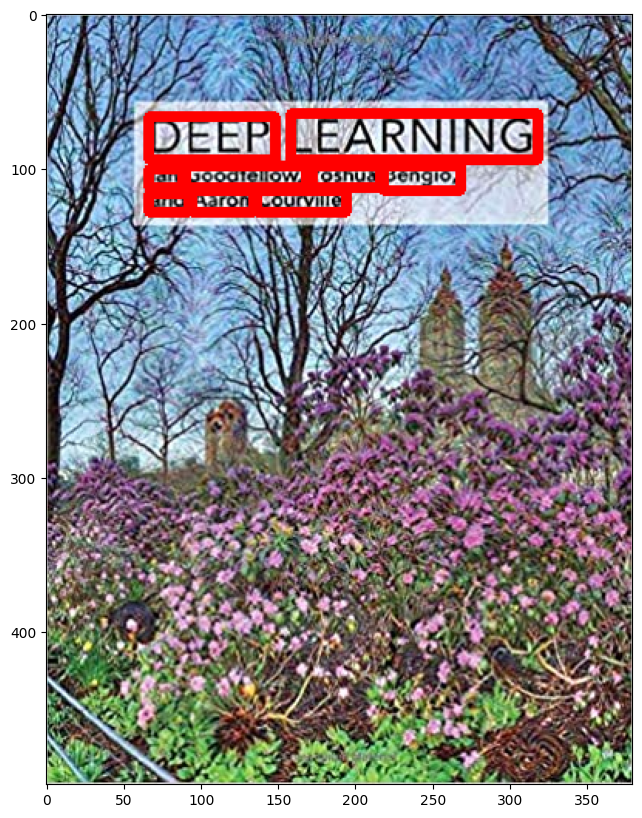

In [8]:
display_boxes(image,detections)

# <font color="blue">6. Recognize Detected Text using Tesseract</font>
We are using the detected text boxes from above to pass it to the Tesseract engine with psm = 6 ( since we expect the boxes to contain a single block of text ).

If the text is recognized, we add the text and box information in a list which is then returned.

In [9]:
def tess_recognize_from_boxes(image, detections, config):
  predictions = []
  # for each box
  for i, box in enumerate(detections):
    # get the cropped and algned image
    cropped_warped = keras_ocr.tools.warpBox(image, box)

    # Perform tesseract OCR on the cropped Text
    text = pytesseract.image_to_string(cropped_warped, config=config)
    
    # Store the text and the corresponding box 
    if text:
      predictions.append((text, box))
  return predictions  

# <font color="blue">7. Modified Pipeline for Detection and Recognition</font>
This function combines the detection (using Keras-ocr) and recognition (using Tesseract). This assumes a psm of 6 unless otherwise specified.

In [10]:
def modified_tesseract(image, config=('--psm 6')):
  # Detect the Text boxes from the image using Keras-ocr
  detections = detector.detect([image])[0]
  
  # Run tesseract on boxes defined above
  predictions = tess_recognize_from_boxes(image, detections, config)

  return predictions

# <font color="blue">8. Display Output </font>
We will use the nice function drawAnnotations available in keras-ocr to display the recognized text as shown below.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


<Axes: >

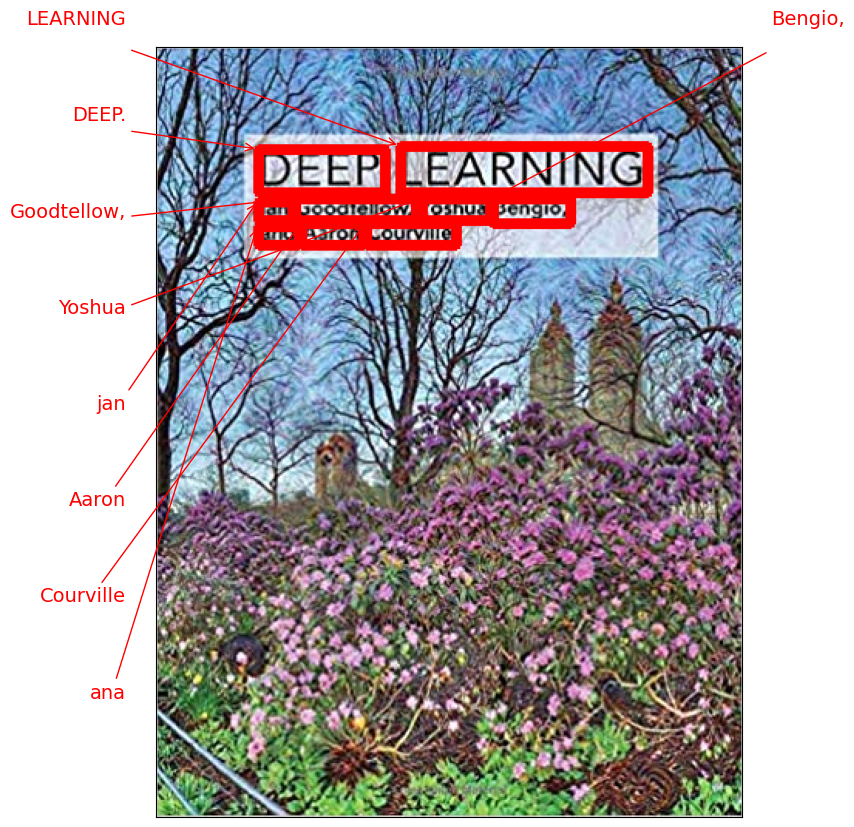

In [11]:
predictions = modified_tesseract(image)
fig,ax = plt.subplots(figsize = [10,10])
keras_ocr.tools.drawAnnotations(image, predictions, ax=ax)

# <font color="blue">9. Comparison with Original Tesseract</font>

## <font color="blue">9.1. Test Image 1: Image of a Book</font>


In [12]:
!wget https://www.dropbox.com/s/uwrdek4jjac4ysz/book2.jpg?dl=1 -O book2.jpg --quiet

### <font color="green">Downloaded Image</font>

<img src="https://www.dropbox.com/s/uwrdek4jjac4ysz/book2.jpg?dl=1" width=500>

### <font color="green">Tesseract Output</font>

In [13]:
book2_text = pytesseract.image_to_string('book2.jpg')
print(book2_text)

The Impact of the Highly Improbable



### <font color="green">Modified Tesseract Output </font>

2025-12-13 15:56:23.279373: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-13 15:56:23.381314: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-13 15:56:23.482831: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-13 15:56:23.903104: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-13 15:56:24.020546: E external/local_xla/xla/stream_

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


<Axes: >

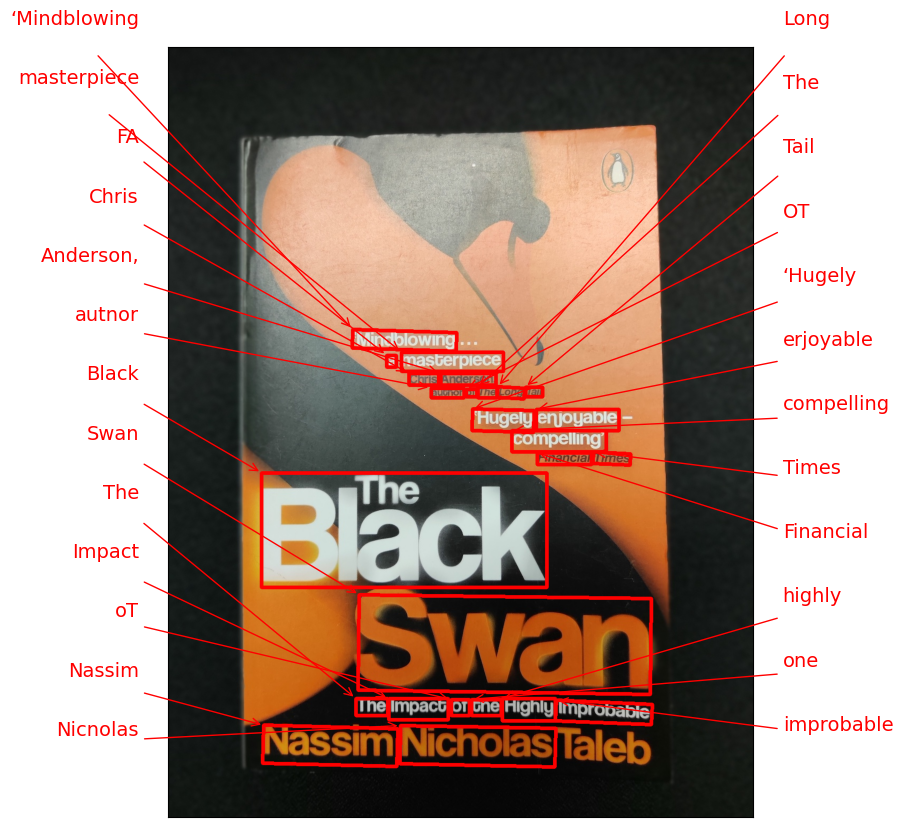

In [14]:
image = keras_ocr.tools.read("book2.jpg")
predictions = modified_tesseract(image)
fig,ax = plt.subplots(figsize = [10,10])
keras_ocr.tools.drawAnnotations(image, predictions, ax=ax)

### <font color="green">Observation </font>
It is able to detect so many of the text which was not recognized earlier. However, it also misses out on those which were recognized earlier like `Impact`, `Highly`. However, we can say that the overall performance has increased considerably for this example.

## <font color="blue">9.2. Street Signs</font>
As we saw in the previous notebook, the default setting could not detect a single word from the street sign images. Let us see if the output improves using the new pipeline!

# <font color="blue">Test Image 2</font>

In [15]:
!wget https://www.dropbox.com/s/uwlnxiihqgni57o/streetsign1.jpg?dl=0 -O streetsign1.jpg --quiet

### <font color="green">Downloaded Image</font>
<img src="https://www.dropbox.com/s/uwlnxiihqgni57o/streetsign1.jpg?dl=1" width=500>

### <font color="green">Modified Tesseract Output</font>

2025-12-13 15:57:22.096000: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-13 15:57:22.330659: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-13 15:57:22.548127: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-13 15:57:22.763139: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng13{} for conv (f32[1,64,2000,3000]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,3,2000,3000]{3,2,1,0}, f32[64,3,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


<Axes: >

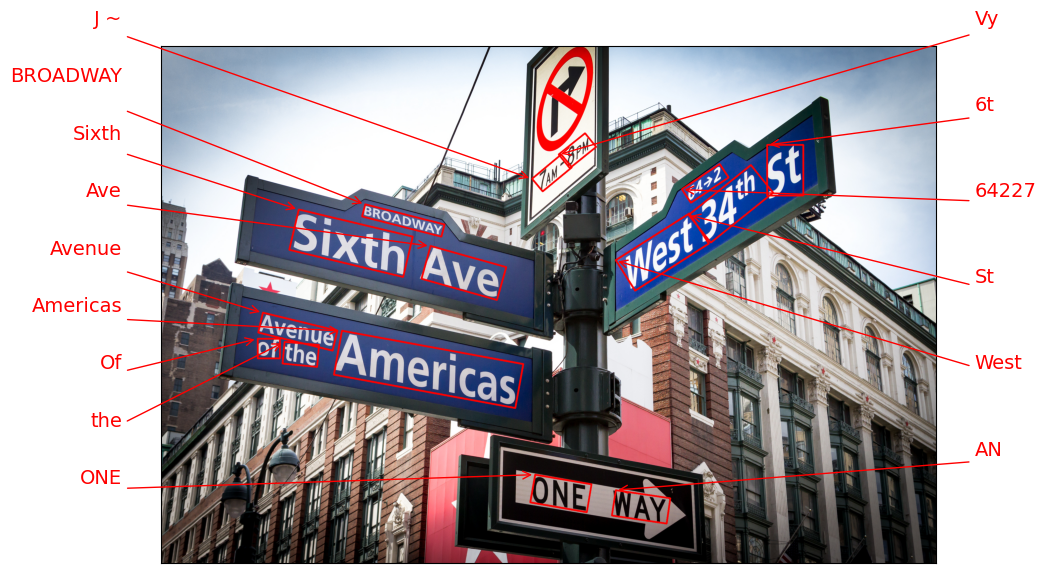

In [16]:
image = keras_ocr.tools.read("streetsign1.jpg")
predictions = modified_tesseract(image)
fig,ax = plt.subplots(figsize = [10,10])
keras_ocr.tools.drawAnnotations(image, predictions, ax=ax)

## <font color="blue">Test Image 3</font>

In [17]:
!wget https://www.dropbox.com/s/dbkag5gsicxqoqg/streetsign2.jpg?dl=0 -O streetsign2.jpg --quiet

### <font color="green">Downloaded Image</font>
<img src="https://www.dropbox.com/s/dbkag5gsicxqoqg/streetsign2.jpg?dl=1" width=500>

### <font color="green">Modified Tesseract Output</font>

2025-12-13 15:57:57.568279: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-13 15:57:57.704848: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-13 15:57:57.833444: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-13 15:57:58.654460: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-13 15:57:58.826016: E external/local_xla/xla/stream_

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


<Axes: >

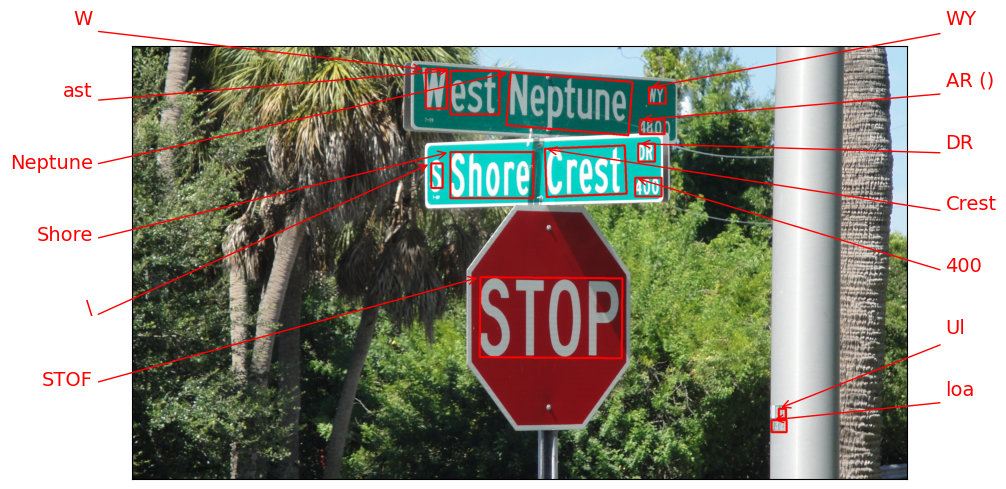

In [18]:
image = keras_ocr.tools.read("streetsign2.jpg")
predictions = modified_tesseract(image)
fig,ax = plt.subplots(figsize = [10,10])
keras_ocr.tools.drawAnnotations(image, predictions, ax=ax)

## <font color="blue">Test Image 4</font>

In [19]:
!wget https://www.dropbox.com/s/cgni28zl1k9sesk/streetsign3.jpg?dl=0 -O streetsign3.jpg --quiet

### <font color="green">Downloaded Image</font>
<img src="https://www.dropbox.com/s/cgni28zl1k9sesk/streetsign3.jpg?dl=1" width=500>

### <font color="green">Modified Tesseract Output</font>

2025-12-13 15:58:20.812719: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-13 15:58:20.900440: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-13 15:58:21.148581: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-13 15:58:21.240199: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-13 15:58:21.782931: W external/local_xla/xla/tsl/fra

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


<Axes: >

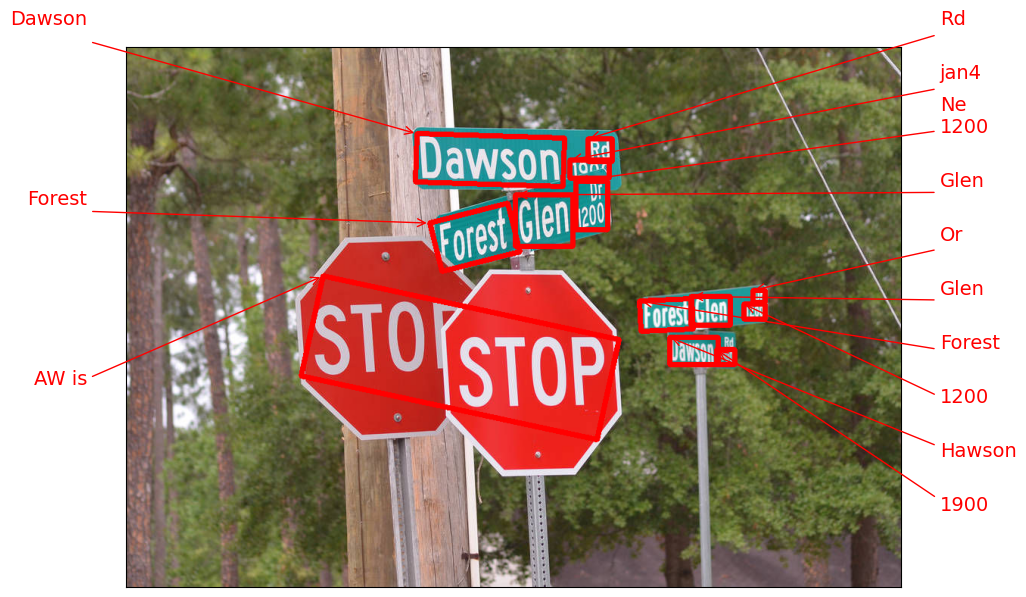

In [20]:
image = keras_ocr.tools.read("streetsign3.jpg")
predictions = modified_tesseract(image)
fig,ax = plt.subplots(figsize = [10,10])
keras_ocr.tools.drawAnnotations(image, predictions, ax=ax)

# <font color="blue">10. Conclusion</font>
We have seen the improvements achieved using the modified pipeline.